# Webinar 4 — Recopilación de datos
**TripleTen · Sprint 12**

---
## Antes de arrancar

> *Una empresa de salud entrena un modelo para predecir si un paciente va a reingresar al hospital en los próximos 30 días. Exactitud: 97%. Lo lanzan. Tres meses después, en producción: 61%.*

**¿Qué crees que salió mal? Escribe en el chat.**

---

## Agenda

| # | Bloque |
|---|--------|
| 1 | Fuentes de datos y exploración | 
| 2 | Data leakage | 
| 3 | Pipeline + Cross validation |
| 4 | GridSearch |
| 5 | Feature importances | 
| 6 | Modelo final | 

**Al terminar vas a poder:**
- Detectar data leakage antes de entrenar
- Construir un pipeline completo de preprocesamiento + modelo
- Evaluar con cross validation y afinar con GridSearch
- Identificar qué features aportan y cuáles son ruido
- Entregar un modelo final listo para producción

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline

#import column tranformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder ,  OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import classification_report

np.random.seed(42)

---
# PARTE 1 — Fuentes de datos y exploración

Dataset de churn de telecomunicaciones — fuente abierta en GitHub.
El objetivo es predecir si un cliente va a cancelar el servicio (`Churn = 1`).

In [ ]:
csv_telecom = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df  = pd.read_csv(csv_telecom)

#¿Qué información deberíamos consultar?

df.head()

Shape:  (7043, 21)
Nulos:  0
Churn:  {'No': 5174, 'Yes': 1869}


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
one_hot_encoding_cols =[] #¿A que columnas les aplicarías one hot encoding?

scaler_cols = [] #¿A que columnas les aplicarías escalado?


---
# PARTE 2 — Data Leakage

Volvamos al caso del inicio. El modelo vio información que en producción no existiría.

**¿Cuál columna tiene la fuga? Escribe en el chat antes de ejecutar la siguiente celda.**

In [38]:
ejemplo = pd.DataFrame({
    'paciente_id':         [1,            2,    3,            4,    5,    6],
    'edad':                [67,           45,   72,           38,   55,   61],
    'dias_internacion':    [8,            2,    12,           1,    4,    9],
    'diagnostico_cronico': [1,            0,    1,            0,    1,    1],
    'fecha_reingreso':     ['2024-03-10', None, '2024-04-02', None, None, '2024-05-18'],

    'reingreso_30d':       [1,            0,    1,            0,    0,    1] # Variable objetivo
})
print(ejemplo.to_string(index=False))

 paciente_id  edad  dias_internacion  diagnostico_cronico fecha_reingreso  reingreso_30d
           1    67                 8                    1      2024-03-10              1
           2    45                 2                    0            None              0
           3    72                12                    1      2024-04-02              1
           4    38                 1                    0            None              0
           5    55                 4                    1            None              0
           6    61                 9                    1      2024-05-18              1


---
# PARTE 3 — Pipeline

Un pipeline encadena el preprocesamiento y el modelo en un solo objeto.
Ventaja clave: cuando llamas `.predict()`, el preprocesamiento se aplica automáticamente — no hay riesgo de olvidar el `transform` en producción.

In [ ]:
# Column tranformer para aplicar distintas transformaciones a distintas columnas

col_transformer = #Crea el column transformer

pipeline_rf = #Crea el pipeline para random forest

pipeline_dt = #Crea el pipeline para decision tree

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one_hot_encoding', ...), ('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

### Cross validation sobre el pipeline

Evaluamos el pipeline completo — no las features crudas, sino el flujo entero incluyendo el preprocesamiento.

In [62]:
# total charges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df.shape)

df = df.dropna(subset=["customerID"])

# Separar en X e y
X = df.drop('Churn', axis=1)
y = df['Churn']

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

(7043, 21)


In [70]:
# Entrenar el modelo con cross validatios

scores = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='f1')


print('F1 por fold:')
for i, s in enumerate(scores):
    print(f'  Fold {i+1}: {"█" * int(s*40)} {s:.4f}')
print(f'\n  Promedio: {scores.mean():.4f}')
print(f'  Std:      {scores.std():.4f}')


scores = cross_val_score(pipeline_dt, X_train, y_train, cv=5, scoring='f1')


print('F1 por fold:')
for i, s in enumerate(scores):
    print(f'  Fold {i+1}: {"█" * int(s*40)} {s:.4f}')
print(f'\n  Promedio: {scores.mean():.4f}')
print(f'  Std:      {scores.std():.4f}')




F1 por fold:
  Fold 1: ███████████████████████ 0.5827
  Fold 2: ██████████████████████ 0.5562
  Fold 3: ███████████████████ 0.4943
  Fold 4: █████████████████████ 0.5379
  Fold 5: ████████████████████ 0.5118

  Promedio: 0.5366
  Std:      0.0314
F1 por fold:
  Fold 1: ████████████████████ 0.5074
  Fold 2: ██████████████████ 0.4674
  Fold 3: ███████████████████ 0.4782
  Fold 4: ████████████████████ 0.5210
  Fold 5: ████████████████████ 0.5043

  Promedio: 0.4956
  Std:      0.0198


---
# PARTE 4 — GridSearch

Con el baseline validado, buscamos los mejores hiperparámetros.
GridSearch prueba todas las combinaciones con cross validation interno — no necesitamos correr `cross_val_score` de nuevo después.

In [77]:
# Los parámetros del pipeline se nombran como 'paso__parametro'
param_grid = {
    'model__n_estimators':  [100, 200],
    'model__max_depth':     [10, 20],
    'model__criterion': ['gini', 'entropy']
}


grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5,
    scoring='f1'
)

grid_search.fit(X_train, y_train)

print(f'\nMejores parámetros: {grid_search.best_params_}')
print(f'Mejor exactitud CV: {grid_search.best_score_:.4f}')


Mejores parámetros: {'model__criterion': 'gini', 'model__max_depth': 10, 'model__n_estimators': 200}
Mejor exactitud CV: 0.6280


---
# PARTE 5 — Feature Importances

Con el modelo afinado, vemos qué features aportan realmente.
Las importancias indican cuánto contribuye cada columna a las decisiones del Random Forest.

In [ ]:
# Extraemos el modelo del mejor pipeline
best_model = grid_search.best_estimator_.named_steps['model']
print(best_model)

x_train_tranformed = col_transformer.fit_transform(X_train)
col_names_trandormed = col_transformer.get_feature_names_out()


importances = pd.Series(
    best_model.feature_importances_,
    index=col_names_trandormed

).sort_values(ascending=False)

print('Top 10 features:')
print(importances.to_string())

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)
Top 10 features:
scaler__tenure                                             0.176382
scaler__TotalCharges                                       0.148836
one_hot_encoding__Contract_Two year                        0.104007
scaler__MonthlyCharges                                     0.103032
one_hot_encoding__InternetService_Fiber optic              0.065593
one_hot_encoding__PaymentMethod_Electronic check           0.047641
one_hot_encoding__Contract_One year                        0.040812
one_hot_encoding__OnlineSecurity_Yes                       0.029926
one_hot_encoding__TechSupport_Yes                          0.025731
one_hot_encoding__PaperlessBilling_Yes                     0.020672
one_hot_encoding__StreamingMovies_No internet service      0.016151
one_hot_encoding__OnlineBackup_Yes                         0.015104
one_hot_encoding__Partner_Yes                  

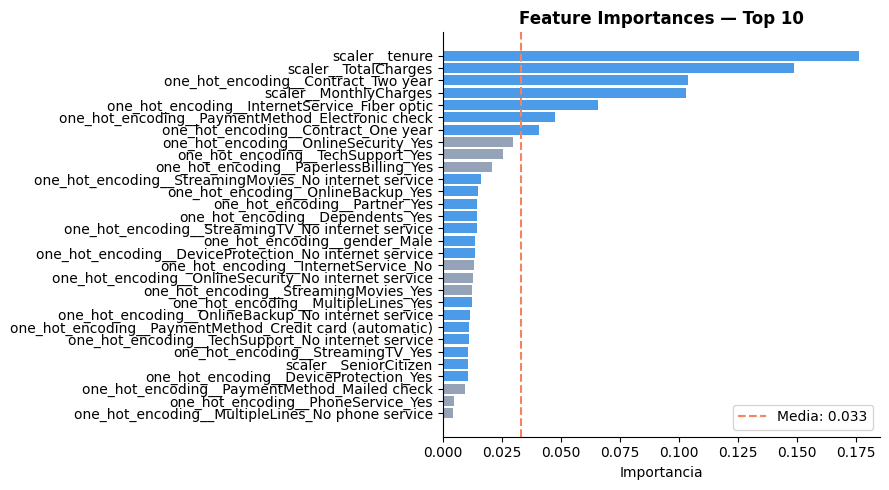


Features por debajo de la media (0.033) → candidatas a eliminar:
['one_hot_encoding__OnlineSecurity_Yes', 'one_hot_encoding__TechSupport_Yes', 'one_hot_encoding__PaperlessBilling_Yes', 'one_hot_encoding__StreamingMovies_No internet service', 'one_hot_encoding__OnlineBackup_Yes', 'one_hot_encoding__Partner_Yes', 'one_hot_encoding__Dependents_Yes', 'one_hot_encoding__StreamingTV_No internet service', 'one_hot_encoding__gender_Male', 'one_hot_encoding__DeviceProtection_No internet service', 'one_hot_encoding__InternetService_No', 'one_hot_encoding__OnlineSecurity_No internet service', 'one_hot_encoding__StreamingMovies_Yes', 'one_hot_encoding__MultipleLines_Yes', 'one_hot_encoding__OnlineBackup_No internet service', 'one_hot_encoding__PaymentMethod_Credit card (automatic)', 'one_hot_encoding__TechSupport_No internet service', 'one_hot_encoding__StreamingTV_Yes', 'scaler__SeniorCitizen', 'one_hot_encoding__DeviceProtection_Yes', 'one_hot_encoding__PaymentMethod_Mailed check', 'one_hot_enc

In [96]:
top10 = importances.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4C9BE8' if v > importances.mean() else '#94A3B8' for v in top10]
ax.barh(importances.index[::-1], importances.values[::-1], color=colors[::-1], edgecolor='none')
ax.axvline(importances.mean(), color='#F4845F', linestyle='--', linewidth=1.5, label=f'Media: {importances.mean():.3f}')
ax.set_xlabel('Importancia')
ax.set_title('Feature Importances — Top 10', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\nFeatures por debajo de la media ({importances.mean():.3f}) → candidatas a eliminar:')
print(importances[importances < importances.mean()].index.tolist())

---
# PARTE 6 — Modelo final

Entrenamos con los mejores parámetros sobre todo el dataset.
Sin dividir en folds — aprovechamos todos los datos disponibles.

In [97]:
# Seleccionamos solo las features que superan la media de importancia
features_seleccionadas = importances[importances >= importances.mean()].index.tolist()
print(f'Features seleccionadas ({len(features_seleccionadas)}): {features_seleccionadas}')

Features seleccionadas (7): ['scaler__tenure', 'scaler__TotalCharges', 'one_hot_encoding__Contract_Two year', 'scaler__MonthlyCharges', 'one_hot_encoding__InternetService_Fiber optic', 'one_hot_encoding__PaymentMethod_Electronic check', 'one_hot_encoding__Contract_One year']


In [ ]:
from sklearn.feature_selection import SelectFromModel

# Pipeline final con las features seleccionadas, montar el pipeline con el la selección de columnas


pipeline_rf.fit(X_train, y_train)
print('Modelo final entrenado ✅')
print(f'Features: {len(features_seleccionadas)}')
print(f'Muestras de entrenamiento: {len(y_train)}')

pipeline_rf



Modelo final entrenado ✅
Features: 7
Muestras de entrenamiento: 5634


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('fcol_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one_hot_encoding', ...), ('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [106]:
# Evaluación rápida sobre train (referencia) + reporte completo
y_pred = pipeline_rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['No churn', 'Churn']))

              precision    recall  f1-score   support

    No churn       0.90      0.78      0.83      1036
       Churn       0.55      0.77      0.64       373

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



---
# Resumen

| Paso | Qué hace | Para qué sirve |
|------|----------|----------------|
| **Data leakage** | Detectar columnas del futuro | Evitar modelos que hacen trampa |
| **Pipeline** | Encadenar preprocesamiento + modelo | Reproducible y seguro en producción |
| **Cross validation** | Evaluar el baseline con K folds | Saber si el enfoque es razonable |
| **GridSearch** | Buscar mejores hiperparámetros | Afinar sin perder generalización |
| **Feature importances** | Ver qué columnas aportan | Reducir ruido y simplificar el modelo |
| **Modelo final** | Entrenar con todo el dataset | Aprovechar al máximo los datos |

---
### Volvamos al caso del inicio

> El modelo pasó de 97% a 61% en producción.

La columna `fecha_reingreso` estaba en el dataset de entrenamiento pero no existe al momento de predecir. El pipeline no lo detecta solo — es responsabilidad del data scientist revisar cada feature antes de entrenar.

**Regla:** antes de meter una columna al modelo, preguntá — *¿esta información estaría disponible en el momento real de la predicción?*